# Experimentos — Balanceador de Carga (MC714, Trabalho 1)

Este notebook executa e documenta os **Experimentos** pedidos em `MC714_enunciado.pdf`
(seção *Experimentos* e *Modelagem analítica*, itens (a)–(f)), usando a biblioteca
já desenvolvida em [`src/load_balancer_sim`](../src/load_balancer_sim).

## Modelo do sistema (conforme o enunciado)

* Um *dispatcher* instantâneo recebe um processo de chegadas **Poisson(λ)** e roteia
  cada requisição para um dos **3 servidores homogêneos**.
* Cada servidor tem **uma única thread de execução** (processa uma requisição por vez)
  e uma **fila FIFO ilimitada** — ou seja, cada servidor é uma fila **M/M/1**.
* O tempo de serviço é **exponencial** de média `1/μ`, com `μ = 1,0`.
* Três políticas de roteamento devem ser comparadas:
  1. **Aleatória** — sorteio uniforme entre os 3 servidores (`p = 1/3` cada);
  2. **Round Robin** — distribuição cíclica `(1, 2, 3, 1, 2, 3, ...)`;
  3. **Fila Mais Curta** — menor `fila + em execução`, com empates resolvidos aleatoriamente.

## O que este notebook faz

1. Importa e reutiliza os componentes já implementados em `load_balancer_sim`
   (`SimulationConfig`, `Request`, `Server`, `LoadBalancer`, `PoissonTrafficGenerator`,
   `MetricsCollector`, `SimulationLogger`).
2. Expõe uma **configuração para selecionar a política** de balanceamento ativa,
   usada nas seções de demonstração/log detalhado.
3. Implementa o motor de simulação de uma réplica (chegadas → roteamento → serviço →
   métricas), com remoção de período de aquecimento (*warm-up*).
4. Executa a matriz completa de experimentos exigida:
   `λ ∈ {0,6; 1,2; 1,8; 2,4; 2,7}` × 3 políticas × **10 réplicas** cada
   (15 configurações, 150 execuções), com horizonte de **5000** u.t. e
   **500** u.t. de aquecimento descartadas.
5. Deduz e calcula o **modelo analítico M/M/1** (válido para a política aleatória)
   e compara com os resultados simulados das três políticas (itens (a)–(e)).
6. Executa o experimento adicional com `λ = 3,3` e analisa a **instabilidade**
   do sistema (item (f)), comparando com a aproximação fluida.
7. Produz tabelas, gráficos com barras de erro de 95% e logs detalhados da
   dinâmica de roteamento, prontos para uso no relatório.


## 1. Importação das bibliotecas

In [15]:
from __future__ import annotations

import logging
import math
from dataclasses import dataclass, field
from itertools import product
from random import Random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import simpy
from scipy import stats

from load_balancer_sim import (
    MetricsCollector,
    Request,
    Server,
    SimulationConfig,
    SimulationLogger,
)
from load_balancer_sim.load_balancer import LoadBalancer
from load_balancer_sim.traffic import PoissonTrafficGenerator

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Configuração geral da simulação

Os parâmetros abaixo reproduzem exatamente o modelo do sistema descrito no
enunciado (Figura da Seção 1, "Modelo do sistema"): 3 servidores homogêneos,
cada um com capacidade `1` (uma única thread) e fila FIFO ilimitada, tempo de
serviço exponencial de média `1/μ` com `μ = 1,0`. Os valores de `λ` do
experimento principal e o protocolo de medição (horizonte, aquecimento,
réplicas) também vêm diretamente do enunciado.

### 3. Seleção de política — configuração do balanceador

O enunciado exige que "o programa deve ter uma opção de configuração para
alternar entre" as três políticas. A célula abaixo define exatamente essa
opção: a variável `SELECTED_POLICY`. Ela controla qual política é usada nas
seções de **demonstração** (execução única com logs detalhados). A varredura
completa de experimentos (Seção 6) executa as **três políticas automaticamente**,
pois o enunciado pede a comparação entre elas — mas qualquer execução avulsa
neste notebook (ou via `python -m load_balancer_sim...`, se desejado) pode ser
direcionada só pela troca desta variável.


In [16]:
# ---------------------------------------------------------------------------
# Modelo do sistema (fixo, conforme o enunciado)
# ---------------------------------------------------------------------------
SERVER_COUNT = 3          # 3 servidores homogeneos
SERVER_CAPACITY = 1       # uma unica thread de execucao por servidor (M/M/1)
MU = 1.0                  # taxa de servico media (E[S] = 1/MU = 1 u.t.)

# ---------------------------------------------------------------------------
# Protocolo de medicao (fixo, conforme o enunciado)
# ---------------------------------------------------------------------------
HORIZON = 5000.0          # duracao de cada execucao (u.t.)
WARMUP = 500.0             # periodo de aquecimento descartado (u.t.)
N_REPLICATIONS = 10       # replicas independentes por configuracao
CONFIDENCE_LEVEL = 0.95

# lambdas do experimento principal (secao "Experimentos" do enunciado)
LAMBDAS = (0.6, 1.2, 1.8, 2.4, 2.7)
# lambda adicional para observar a instabilidade das filas (item (f))
UNSTABLE_LAMBDA = 3.3

BASE_SEED = 12345

ALL_POLICIES: tuple[str, ...] = ("random", "round_robin", "shortest_queue")
POLICY_LABELS = {
    "random": "Aleatória",
    "round_robin": "Round Robin",
    "shortest_queue": "Fila Mais Curta",
}

print(f"mu = {MU}, E[S] = {1 / MU} u.t., servidores = {SERVER_COUNT} (capacidade {SERVER_CAPACITY} cada)")
print(f"Horizonte = {HORIZON} u.t., aquecimento = {WARMUP} u.t., replicas = {N_REPLICATIONS}")
print(f"Lambdas do experimento principal: {LAMBDAS}")


mu = 1.0, E[S] = 1.0 u.t., servidores = 3 (capacidade 1 cada)
Horizonte = 5000.0 u.t., aquecimento = 500.0 u.t., replicas = 10
Lambdas do experimento principal: (0.6, 1.2, 1.8, 2.4, 2.7)


In [17]:
# ---------------------------------------------------------------------------
# CONFIGURAÇÃO DA POLÍTICA ATIVA — altere esta variável para trocar de política
# nas seções de demonstração (Seção 5). Valores válidos: ver ALL_POLICIES acima.
# ---------------------------------------------------------------------------
SELECTED_POLICY = "shortest_queue"  # "random" | "round_robin" | "shortest_queue"

assert SELECTED_POLICY in ALL_POLICIES, (
    f"Política desconhecida: {SELECTED_POLICY!r}. Use uma de {ALL_POLICIES}."
)

print(f"Política selecionada para a demonstração: {POLICY_LABELS[SELECTED_POLICY]!r}")


Política selecionada para a demonstração: 'Fila Mais Curta'


## 4. Motor de simulação de uma réplica

Cada réplica monta, a partir dos blocos já existentes em `load_balancer_sim`:

* um `simpy.Environment`;
* 3 `Server` (capacidade 1, tempo de serviço amostrado de uma exponencial de
  média `1/μ`, via o parâmetro `rng` adicionado);
* um `LoadBalancer` com a política escolhida;
* um `PoissonTrafficGenerator` gerando chegadas de taxa `λ`;
* um `MetricsCollector` + `SimulationLogger`, para os *logs detalhados* exigidos
  pelo enunciado (dinâmica de roteamento: qual servidor recebeu cada requisição
  e quando).

### Sementes independentes

Para reduzir variância nas comparações **entre políticas** (mesmo tráfego e
mesmos tempos de serviço, apenas a decisão de roteamento muda — uma técnica de
"números aleatórios comuns"), cada réplica usa três fluxos de aleatoriedade
independentes, derivados de uma única semente base:

* `arrival_seed`: chegadas Poisson (compartilhada entre as 3 políticas, mesma
  réplica/λ);
* `service_seed`: tempos de serviço exponenciais (idem, compartilhada);
* `routing_seed`: decisões de roteamento (Aleatória / desempate da Fila Mais
  Curta) — varia por política, para não correlacionar artificialmente as
  decisões de roteamento entre políticas distintas.

### Remoção do período de aquecimento (*warm-up*)

A simulação roda do instante `0` até `HORIZON`, mas as métricas oficiais só
consideram a janela `[WARMUP, HORIZON]`:

* **Vazão `X`**: requisições concluídas com `completion_time` na janela, dividido
  pela duração da janela;
* **Tempo médio de resposta `E[R]`**: média de `completion_time - arrival_time`
  das requisições concluídas na janela;
* **Número médio no sistema `E[N]`**: *área sob a curva* de ocupação do sistema
  (chegadas `+1`, conclusões `-1`) integrada no tempo sobre a janela e dividida
  pela duração da janela — exatamente a recomendação da Seção "Dicas" do
  enunciado (evitar médias sobre chegadas);
* **Utilização por servidor `U_i`**: fração do tempo, dentro da janela, em que
  o servidor `i` está ocupado (`active_count = 1`), também via integração no
  tempo a partir do histórico de estados do servidor.


In [4]:
def _time_average(
    events: list[tuple[float, int]],
    window_start: float,
    window_end: float,
) -> float:
    """Integra no tempo um contador que muda em instantes discretos.

    ``events`` e uma lista de pares ``(tempo, delta)`` que incrementam ou
    decrementam um contador inteiro (ocupacao do sistema, servidor ocupado,
    etc.). Retorna a media temporal do contador dentro de
    ``[window_start, window_end]`` (area sob a curva dividida pela duracao).
    """
    ordered = sorted(events, key=lambda item: item[0])

    counter = 0
    index = 0
    total = len(ordered)
    while index < total and ordered[index][0] <= window_start:
        counter += ordered[index][1]
        index += 1

    area = 0.0
    current_time = window_start
    current_value = counter
    while index < total and ordered[index][0] < window_end:
        event_time, delta = ordered[index]
        area += current_value * (event_time - current_time)
        current_value += delta
        current_time = event_time
        index += 1
    area += current_value * (window_end - current_time)

    return area / (window_end - window_start)


def _build_step_series(
    events: list[tuple[float, int]],
    window_end: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Constroi a serie temporal (degraus) de um contador, a partir de t=0."""
    ordered = sorted(events, key=lambda item: item[0])
    times = [0.0]
    values = [0]
    counter = 0
    for event_time, delta in ordered:
        if event_time > window_end:
            break
        counter += delta
        times.append(event_time)
        values.append(counter)
    times.append(window_end)
    values.append(counter)
    return np.array(times), np.array(values)


print("Funcoes de integracao temporal definidas: _time_average, _build_step_series.")


Funcoes de integracao temporal definidas: _time_average, _build_step_series.


In [5]:
@dataclass(frozen=True, slots=True)
class ReplicationResult:
    """Resumo das metricas oficiais (janela pos-aquecimento) de uma replica."""

    policy: str
    arrival_rate: float
    seed: int
    horizon: float
    warmup: float
    arrivals_in_window: int
    completed_in_window: int
    throughput: float                      # X
    mean_response_time: float | None       # E[R]
    mean_number_in_system: float           # E[N]
    utilizations: tuple[float, ...]        # U_i por servidor
    requests_per_server: tuple[int, ...]   # distribuicao de carga (contagem)


class ListLogHandler(logging.Handler):
    """Handler simples que acumula linhas de log em uma lista em memoria."""

    def __init__(self, capacity: int | None = None) -> None:
        super().__init__()
        self.capacity = capacity
        self.records: list[str] = []

    def emit(self, record: logging.LogRecord) -> None:
        if self.capacity is not None and len(self.records) >= self.capacity:
            return
        self.records.append(self.format(record))


def run_replication(
    policy: str,
    arrival_rate: float,
    seed: int,
    *,
    server_count: int = SERVER_COUNT,
    server_capacity: int = SERVER_CAPACITY,
    mu: float = MU,
    horizon: float = HORIZON,
    warmup: float = WARMUP,
    routing_seed: int | None = None,
    log_handler: logging.Handler | None = None,
) -> tuple[ReplicationResult, list[Request], list[Server]]:
    """Executa uma unica replica e resume as metricas na janela pos-aquecimento.

    Retorna o resumo (:class:`ReplicationResult`), a lista de requisicoes
    observadas e os servidores (uteis para logs/graficos de demonstracao).
    """
    service_time_mean = 1.0 / mu
    arrival_seed = seed
    service_seed = seed + 500_000
    resolved_routing_seed = seed + 900_000 if routing_seed is None else routing_seed

    environment = simpy.Environment()

    config = SimulationConfig(
        policy=policy,  # type: ignore[arg-type]
        server_count=server_count,
        server_capacity=server_capacity,
        service_time=service_time_mean,
        arrival_rate=arrival_rate,
        horizon=horizon,
        seed=arrival_seed,
    )
    routing_config = SimulationConfig(
        policy=policy,  # type: ignore[arg-type]
        server_count=server_count,
        server_capacity=server_capacity,
        service_time=service_time_mean,
        arrival_rate=arrival_rate,
        horizon=horizon,
        seed=resolved_routing_seed,
    )

    simulation_logger = None
    collector = None
    if log_handler is not None:
        simulation_logger = SimulationLogger()
        simulation_logger.logger.addHandler(log_handler)
        simulation_logger.logger.setLevel(logging.DEBUG)
        collector = MetricsCollector(environment, event_handler=simulation_logger.log_event)
        simulation_logger.log_run_started(config)

    service_seed_stream = Random(service_seed)
    servers = [
        Server(
            environment,
            server_id=index,
            capacity=server_capacity,
            service_time=service_time_mean,
            rng=Random(service_seed_stream.getrandbits(63)),
        )
        for index in range(server_count)
    ]

    load_balancer = LoadBalancer(
        environment,
        servers,
        policy=policy,
        simulation_config=routing_config,
    )

    all_requests: list[Request] = []

    def on_arrival(request: Request) -> None:
        all_requests.append(request)
        if collector is not None:
            collector.record_arrival(request)
        selected_server = load_balancer.route_request(request)
        if collector is not None:
            collector.record_routing(request, selected_server)

    traffic_generator = PoissonTrafficGenerator(
        environment,
        arrival_rate=arrival_rate,
        horizon=horizon,
        seed=arrival_seed,
    )
    environment.process(traffic_generator.run(on_arrival))
    environment.run(until=horizon)

    if simulation_logger is not None and log_handler is not None:
        simulation_logger.logger.removeHandler(log_handler)

    result = _summarize_replication(
        policy=policy,
        arrival_rate=arrival_rate,
        seed=seed,
        horizon=horizon,
        warmup=warmup,
        requests=all_requests,
        servers=servers,
    )
    return result, all_requests, servers


def _summarize_replication(
    *,
    policy: str,
    arrival_rate: float,
    seed: int,
    horizon: float,
    warmup: float,
    requests: list[Request],
    servers: list[Server],
) -> ReplicationResult:
    window = horizon - warmup

    completed_in_window = [
        request
        for request in requests
        if request.completion_time is not None
        and warmup <= request.completion_time <= horizon
    ]
    response_times = [
        request.completion_time - request.arrival_time  # type: ignore[operator]
        for request in completed_in_window
    ]
    arrivals_in_window = sum(
        1 for request in requests if warmup <= request.arrival_time < horizon
    )

    occupancy_events: list[tuple[float, int]] = []
    for request in requests:
        occupancy_events.append((request.arrival_time, 1))
        if request.completion_time is not None:
            occupancy_events.append((request.completion_time, -1))
    mean_number_in_system = _time_average(occupancy_events, warmup, horizon)

    utilizations: list[float] = []
    requests_per_server: list[int] = []
    for server in servers:
        busy_events = [
            (state.time, 1 if state.event == "service_started" else -1)
            for state in server.state_history
            if state.event in ("service_started", "service_completed")
        ]
        utilizations.append(_time_average(busy_events, warmup, horizon))
        requests_per_server.append(server.completed_count)

    return ReplicationResult(
        policy=policy,
        arrival_rate=arrival_rate,
        seed=seed,
        horizon=horizon,
        warmup=warmup,
        arrivals_in_window=arrivals_in_window,
        completed_in_window=len(completed_in_window),
        throughput=len(completed_in_window) / window,
        mean_response_time=float(np.mean(response_times)) if response_times else None,
        mean_number_in_system=mean_number_in_system,
        utilizations=tuple(utilizations),
        requests_per_server=tuple(requests_per_server),
    )


print("Motor de simulacao definido: run_replication(...) -> ReplicationResult.")


Motor de simulacao definido: run_replication(...) -> ReplicationResult.


## 5. Demonstração com logs detalhados e cheque de sanidade

Antes de rodar a matriz completa, fazemos uma execução única com a política
selecionada em `SELECTED_POLICY` (Seção 3), habilitando o log `DEBUG` do
`SimulationLogger`. Isso atende ao requisito de "logs detalhados... da dinâmica
de distribuição de carga" e serve de **cheque de sanidade**: com `λ` muito
pequeno, `E[R]` deve tender a `E[S] = 1` u.t. para qualquer política (dica do
enunciado, Seção 3).


In [7]:
# Cheque de sanidade: lambda muito pequeno -> E[R] deve tender a E[S] = 1/mu
sanity_handler = ListLogHandler(capacity=20)
sanity_handler.setFormatter(logging.Formatter("%(levelname)s %(message)s"))

sanity_result, _, _ = run_replication(
    policy=SELECTED_POLICY,
    arrival_rate=0.05,
    seed=BASE_SEED,
    horizon=5000.0,
    warmup=200.0,
    log_handler=sanity_handler,
)

print(f"Política: {POLICY_LABELS[SELECTED_POLICY]}  (lambda = 0.05, sistema quase ocioso)")
print(
    f"E[R] simulado = {sanity_result.mean_response_time:.4f}  "
    f"(esperado ~= {1 / MU:.4f}, n = {sanity_result.completed_in_window} conclusões)"
)
assert sanity_result.mean_response_time is not None
assert abs(sanity_result.mean_response_time - 1.0 / MU) < 0.3, "cheque de sanidade falhou"
print("Cheque de sanidade OK: E[R] tende a E[S] quando o sistema está quase ocioso.")


Política: Fila Mais Curta  (lambda = 0.05, sistema quase ocioso)
E[R] simulado = 0.9785  (esperado ~= 1.0000, n = 255 conclusões)
Cheque de sanidade OK: E[R] tende a E[S] quando o sistema está quase ocioso.


In [8]:
# Demonstração com carga moderada (lambda = 1.8) e a política selecionada.
demo_handler = ListLogHandler(capacity=25)
demo_handler.setFormatter(logging.Formatter("%(levelname)s %(message)s"))

demo_result, demo_requests, demo_servers = run_replication(
    policy=SELECTED_POLICY,
    arrival_rate=1.8,
    seed=BASE_SEED,
    log_handler=demo_handler,
)

print(f"--- Amostra do log DEBUG (primeiras {len(demo_handler.records)} linhas) ---")
print("\n".join(demo_handler.records))

print("\n--- Resumo da réplica (janela pós-aquecimento) ---")
print(f"Política: {POLICY_LABELS[SELECTED_POLICY]}, lambda = 1.8")
print(f"Chegadas na janela: {demo_result.arrivals_in_window}")
print(f"Concluídas na janela: {demo_result.completed_in_window}")
print(f"Vazão X = {demo_result.throughput:.4f} req/u.t.")
print(f"E[R] = {demo_result.mean_response_time:.4f} u.t.")
print(f"E[N] = {demo_result.mean_number_in_system:.4f} requisições")
print(f"Requisições atendidas por servidor: {demo_result.requests_per_server}")
print(f"Utilização U_i por servidor: {[round(u, 4) for u in demo_result.utilizations]}")


--- Amostra do log DEBUG (primeiras 25 linhas) ---
INFO run_started,policy=shortest_queue,server_count=3,server_capacity=1,service_time=1.000000,arrival_rate=1.800000,horizon=5000.000000,seed=12345
DEBUG time,event,request_id,burst_id,server_id,active,queue_length
DEBUG 0.299398,arrival,0,0,,,
DEBUG 0.299398,routing,0,0,0,0,0
DEBUG 0.305076,arrival,1,0,,,
DEBUG 0.305076,routing,1,0,2,0,0
DEBUG 1.274049,arrival,2,0,,,
DEBUG 1.274049,routing,2,0,0,0,0
DEBUG 1.471123,arrival,3,0,,,
DEBUG 1.471123,routing,3,0,2,0,0
DEBUG 1.726410,arrival,4,0,,,
DEBUG 1.726410,routing,4,0,1,0,0
DEBUG 1.845995,arrival,5,0,,,
DEBUG 1.845995,routing,5,0,1,1,0
DEBUG 2.309733,arrival,6,0,,,
DEBUG 2.309733,routing,6,0,2,0,0
DEBUG 2.407714,arrival,7,0,,,
DEBUG 2.407714,routing,7,0,0,1,0
DEBUG 2.481432,arrival,8,0,,,
DEBUG 2.481432,routing,8,0,2,1,0
DEBUG 2.796590,arrival,9,0,,,
DEBUG 2.796590,routing,9,0,1,1,0
DEBUG 3.255321,arrival,10,0,,,
DEBUG 3.255321,routing,10,0,0,1,1
DEBUG 3.361752,arrival,11,0,,,

--- Resu

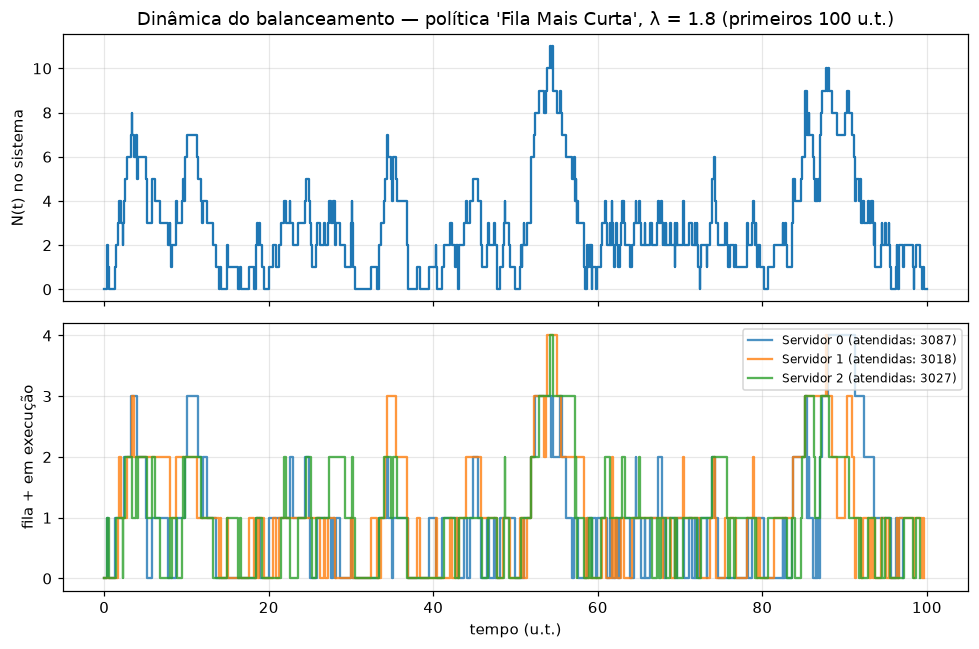

In [9]:
# Dinâmica de ocupação das filas ao longo do tempo (janela inicial, para visualização)
plot_window_end = 100.0

occupancy_events = [(r.arrival_time, 1) for r in demo_requests]
occupancy_events += [
    (r.completion_time, -1) for r in demo_requests if r.completion_time is not None
]
system_times, system_values = _build_step_series(occupancy_events, plot_window_end)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].step(system_times, system_values, where="post", color="tab:blue")
axes[0].set_ylabel("N(t) no sistema")
axes[0].set_title(
    f"Dinâmica do balanceamento — política {POLICY_LABELS[SELECTED_POLICY]!r}, "
    f"λ = 1.8 (primeiros {plot_window_end:.0f} u.t.)"
)

for server in demo_servers:
    queue_events = [
        (state.time, state.active_count + state.waiting_count)
        for state in server.state_history
        if state.event != "initialized"
    ]
    times = [0.0] + [t for t, _ in queue_events]
    values = [0] + [v for _, v in queue_events]
    mask_times = [t for t in times if t <= plot_window_end]
    mask_values = values[: len(mask_times)]
    axes[1].step(
        mask_times,
        mask_values,
        where="post",
        label=f"Servidor {server.id} (atendidas: {server.completed_count})",
        alpha=0.8,
    )

axes[1].set_ylabel("fila + em execução")
axes[1].set_xlabel("tempo (u.t.)")
axes[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## 6. Modelagem analítica (válida para a política Aleatória)

Esta seção implementa a dedução pedida nos itens (a)–(b) do enunciado.

### (a) Decomposição (*splitting*) do processo de Poisson

Sob a política **Aleatória**, cada requisição que chega ao sistema segundo um
processo de Poisson de taxa `λ` é encaminhada de forma **independente e
identicamente distribuída (i.i.d.)** para o servidor `i ∈ {1, 2, 3}` com
probabilidade `p_i = 1/3`, independentemente do passado e de qualquer outra
requisição.

O **teorema da decomposição de Poisson** (*splitting*) afirma que, se um
processo de Poisson de taxa `λ` é dividido em `k` subprocessos por meio de
marcações i.i.d. independentes da história do processo (aqui, `k = 3` e
`p_i = 1/3`), então:

1. cada subprocesso `i` é, por si só, um processo de Poisson de taxa
   `λ_i = p_i · λ = λ/3`;
2. os `k` subprocessos são **mutuamente independentes** entre si.

Isso decorre diretamente da propriedade de que, em um processo de Poisson,
o número de chegadas em intervalos disjuntos é independente, e cada marcação
(sorteio do servidor) é um ensaio de Bernoulli independente. Formalmente, se
`N(t)` é Poisson(`λt`) e cada chegada é marcada com o servidor `i` de forma
i.i.d., então `N_i(t) | N(t) = n` é Binomial(`n, 1/3`), e marginalizando sobre
`N(t) ~ Poisson(λt)` obtém-se `N_i(t) ~ Poisson(λt/3)`; a independência entre
`N_1(t), N_2(t), N_3(t)` segue da função geratriz de probabilidade conjunta,
que se fatora em produto de Poissons independentes — este é exatamente o
resultado clássico de decomposição do processo de Poisson.

**Portanto**, sob a política Aleatória, cada um dos 3 servidores recebe um
processo de Poisson de taxa `λ_i = λ/3`, e os três fluxos de chegada são
independentes entre si.

### (b) Cada servidor é uma fila M/M/1

Como cada servidor tem uma única thread (capacidade 1), fila FIFO ilimitada,
chegadas Poisson(`λ/3`) (item (a)) e tempo de serviço exponencial de média
`1/μ`, cada servidor é **exatamente uma fila M/M/1** com `ρ = λ_i/μ = λ/(3μ)`.

Da distribuição estacionária `p_k = (1 - ρ) ρ^k` (`k = 0, 1, 2, ...`), válida
sob a **condição de estabilidade `ρ < 1`**, isto é, `λ < 3μ`:

$$
U_i = \rho = \frac{\lambda}{3\mu}
\qquad\text{(fração do tempo ocupado; } U_i = 1 - p_0\text{)}
$$

$$
E[N_i] = \sum_{k=0}^{\infty} k\, p_k = \frac{\rho}{1-\rho}
= \frac{\lambda_i}{\mu - \lambda_i}
$$

$$
E[R] = \frac{1}{\mu - \lambda_i} = \frac{1}{\mu - \lambda/3}
\qquad\text{(Lei de Little: } E[N_i] = \lambda_i \cdot E[R]\text{)}
$$

$$
E[T_Q] = E[R] - \frac{1}{\mu} = \frac{\rho}{\mu - \lambda_i}
= \frac{\lambda_i}{\mu(\mu - \lambda_i)}
$$

A **vazão** do sistema, em regime estacionário (`ρ < 1`), é `X = λ` (toda
requisição que chega acaba sendo atendida — conservação de trabalho).

### (c) A vazão e a utilização valem para as três políticas

O argumento de **conservação de trabalho** não depende da política de
roteamento: toda requisição que chega ao sistema é, mais cedo ou mais tarde,
atendida por **algum** servidor (nenhuma política descarta requisições, e a
fila de cada servidor é ilimitada). Logo, em regime estacionário
(`λ < 3μ`), a vazão agregada do sistema é sempre `X = λ`, **independentemente**
de qual política de roteamento é usada.

Além disso, como os 3 servidores são homogêneos e cada requisição é atendida
por exatamente um servidor, a soma das taxas de atendimento efetivas dos 3
servidores também é `λ` em regime estacionário — e por simetria (nenhuma
política favorece estruturalmente um servidor específico), a utilização
**média** de cada servidor tende a `U_i = λ/(3μ)`, igual à prevista pelo
modelo M/M/1 do item (b). A Seção 8 confirma isso empiricamente para as três
políticas.

O que **muda** entre as políticas é a forma como a carga é distribuída no
tempo (rajadas momentâneas em um servidor enquanto outro está ocioso), o que
afeta o **tempo de resposta** `E[R]` — mas não a vazão nem a utilização média
de longo prazo.


In [10]:
@dataclass(frozen=True, slots=True)
class AnalyticalMetrics:
    arrival_rate: float
    mu: float
    lambda_i: float          # taxa por servidor (lambda / 3)
    rho: float                # utilizacao teorica U_i
    stable: bool
    mean_response_time: float | None   # E[R]
    mean_queue_time: float | None      # E[Tq]
    mean_number_per_server: float | None  # E[N_i]
    mean_number_system: float | None      # E[N] = 3 * E[N_i]
    throughput: float | None              # X = lambda (se estavel)


def analytical_mm1_metrics(
    arrival_rate: float,
    mu: float = MU,
    server_count: int = SERVER_COUNT,
) -> AnalyticalMetrics:
    """Modelo M/M/1 por servidor sob a politica Aleatoria (itens (a)-(b))."""
    lambda_i = arrival_rate / server_count
    rho = lambda_i / mu
    stable = rho < 1.0

    if not stable:
        return AnalyticalMetrics(
            arrival_rate=arrival_rate,
            mu=mu,
            lambda_i=lambda_i,
            rho=rho,
            stable=False,
            mean_response_time=None,
            mean_queue_time=None,
            mean_number_per_server=None,
            mean_number_system=None,
            throughput=None,
        )

    mean_response_time = 1.0 / (mu - lambda_i)
    mean_queue_time = mean_response_time - 1.0 / mu
    mean_number_per_server = rho / (1.0 - rho)
    return AnalyticalMetrics(
        arrival_rate=arrival_rate,
        mu=mu,
        lambda_i=lambda_i,
        rho=rho,
        stable=True,
        mean_response_time=mean_response_time,
        mean_queue_time=mean_queue_time,
        mean_number_per_server=mean_number_per_server,
        mean_number_system=server_count * mean_number_per_server,
        throughput=arrival_rate,
    )


analytical_rows = [analytical_mm1_metrics(lam) for lam in LAMBDAS]
analytical_table = pd.DataFrame(
    {
        "lambda": [row.arrival_rate for row in analytical_rows],
        "lambda_i = lambda/3": [row.lambda_i for row in analytical_rows],
        "rho = U_i (teórico)": [row.rho for row in analytical_rows],
        "estável (rho<1)": [row.stable for row in analytical_rows],
        "E[R] teórico": [row.mean_response_time for row in analytical_rows],
        "E[Tq] teórico": [row.mean_queue_time for row in analytical_rows],
        "E[N_i] teórico": [row.mean_number_per_server for row in analytical_rows],
        "E[N] teórico (sistema)": [row.mean_number_system for row in analytical_rows],
        "X teórico": [row.throughput for row in analytical_rows],
    }
).round(4)

analytical_table


,lambda,lambda_i = lambda/3,rho = U_i (teórico),estável (rho<1),E[R] teórico,E[Tq] teórico,E[N_i] teórico,E[N] teórico (sistema),X teórico
0,0.6,0.2,0.2,True,1.2500,0.2500,0.2500,0.75,0.6
1,1.2,0.4,0.4,True,1.6667,0.6667,0.6667,2.00,1.2
2,1.8,0.6,0.6,True,2.5000,1.5000,1.5000,4.50,1.8
3,2.4,0.8,0.8,True,5.0000,4.0000,4.0000,12.00,2.4
4,2.7,0.9,0.9,True,10.0000,9.0000,9.0000,27.00,2.7


## 7. Execução da matriz completa de experimentos

Agora executamos as **15 configurações** exigidas
(`3 políticas × 5 valores de λ`), cada uma com **10 réplicas** independentes,
totalizando **150 execuções** — cada uma simulando `HORIZON = 5000` u.t. e
descartando os primeiros `WARMUP = 500` u.t.

Como combinado na Seção 4, a semente de chegadas/serviço depende apenas de
`(λ, réplica)` — e é **reaproveitada pelas três políticas** — enquanto a
semente de roteamento depende também da política. Isso garante que, para uma
mesma réplica e o mesmo `λ`, as três políticas enfrentem exatamente o mesmo
tráfego de chegadas e os mesmos tempos de serviço, isolando o efeito da
política de roteamento nas métricas.


In [11]:
def _seed_for(arrival_rate: float, replication: int) -> int:
    """Semente de chegadas/servico: comum as 3 politicas (mesmo lambda/replica)."""
    lambda_index = LAMBDAS.index(arrival_rate) if arrival_rate in LAMBDAS else 99
    return BASE_SEED + 10_000 * lambda_index + replication


def _routing_seed_for(policy: str, arrival_rate: float, replication: int) -> int:
    """Semente de roteamento: depende tambem da politica."""
    policy_index = ALL_POLICIES.index(policy)
    return _seed_for(arrival_rate, replication) + 900_000 + 1_000 * policy_index


all_results: list[ReplicationResult] = []

for policy, arrival_rate, replication in product(ALL_POLICIES, LAMBDAS, range(N_REPLICATIONS)):
    seed = _seed_for(arrival_rate, replication)
    routing_seed = _routing_seed_for(policy, arrival_rate, replication)
    result, _, _ = run_replication(
        policy=policy,
        arrival_rate=arrival_rate,
        seed=seed,
        routing_seed=routing_seed,
    )
    all_results.append(result)

print(f"Execuções concluídas: {len(all_results)} (esperado: {len(ALL_POLICIES) * len(LAMBDAS) * N_REPLICATIONS})")


Execuções concluídas: 150 (esperado: 150)


## 8. Agregação das métricas (média e IC 95% das 10 réplicas)

Consolidamos as 150 execuções em um `DataFrame` "bruto" (uma linha por réplica)
e depois agregamos por `(política, λ)`, calculando **média** e **intervalo de
confiança de 95%** com a distribuição *t* de Student (`9` graus de liberdade,
pois há 10 réplicas):

$$
\text{IC95} = \bar{x} \pm t_{0{,}975,\,9} \cdot \frac{s}{\sqrt{10}}
$$


In [12]:
raw_rows = []
for result in all_results:
    mean_utilization = float(np.mean(result.utilizations))
    raw_rows.append(
        {
            "policy": result.policy,
            "arrival_rate": result.arrival_rate,
            "seed": result.seed,
            "throughput": result.throughput,
            "mean_response_time": result.mean_response_time,
            "mean_number_in_system": result.mean_number_in_system,
            "mean_utilization": mean_utilization,
            "utilization_server_0": result.utilizations[0],
            "utilization_server_1": result.utilizations[1],
            "utilization_server_2": result.utilizations[2],
            "requests_server_0": result.requests_per_server[0],
            "requests_server_1": result.requests_per_server[1],
            "requests_server_2": result.requests_per_server[2],
        }
    )

raw_df = pd.DataFrame(raw_rows)
print(f"raw_df: {raw_df.shape[0]} linhas (uma por réplica)")
raw_df.head(3)


raw_df: 150 linhas (uma por réplica)


,policy,arrival_rate,seed,throughput,mean_response_time,mean_number_in_system,mean_utilization,utilization_server_0,utilization_server_1,utilization_server_2,requests_server_0,requests_server_1,requests_server_2
0,random,0.6,12345,0.606000,1.196697,0.724206,0.196502,0.185217,0.212015,0.192273,976,1052,1016
1,random,0.6,12346,0.596667,1.271916,0.758838,0.202158,0.210888,0.200989,0.194596,1029,982,964
2,random,0.6,12347,0.594000,1.300340,0.772967,0.201802,0.204429,0.194342,0.206635,1004,966,1015


In [13]:
def _confidence_interval_95(values: pd.Series) -> float:
    """Semi-amplitude do IC 95% usando a distribuicao t de Student (n-1 gl)."""
    values = values.dropna()
    n = len(values)
    if n < 2:
        return float("nan")
    standard_error = values.std(ddof=1) / math.sqrt(n)
    t_critical = stats.t.ppf(0.5 + CONFIDENCE_LEVEL / 2, df=n - 1)
    return t_critical * standard_error


def _aggregate(group: pd.DataFrame) -> pd.Series:
    metrics = [
        "throughput",
        "mean_response_time",
        "mean_number_in_system",
        "mean_utilization",
    ]
    data = {"n_replications": len(group)}
    for metric in metrics:
        data[f"{metric}_mean"] = group[metric].mean()
        data[f"{metric}_ci95"] = _confidence_interval_95(group[metric])
    return pd.Series(data)


summary_df = (
    raw_df.groupby(["policy", "arrival_rate"], as_index=False)
    .apply(_aggregate, include_groups=False)
    .reset_index(drop=True)
)
summary_df["policy_label"] = summary_df["policy"].map(POLICY_LABELS)

print(f"summary_df: {summary_df.shape[0]} linhas (esperado: {len(ALL_POLICIES) * len(LAMBDAS)})")
summary_df.round(4)


summary_df: 15 linhas (esperado: 15)


,policy,arrival_rate,n_replications,throughput_mean,throughput_ci95,mean_response_time_mean,mean_response_time_ci95,mean_number_in_system_mean,mean_number_in_system_ci95,mean_utilization_mean,mean_utilization_ci95,policy_label
0,random,0.6,10.0,0.6059,0.0078,1.2587,0.0288,0.7625,0.0170,0.2023,0.0030,Aleatória
1,random,1.2,10.0,1.2007,0.0094,1.6762,0.0462,2.0132,0.0627,0.4010,0.0060,Aleatória
2,random,1.8,10.0,1.8062,0.0193,2.5572,0.0954,4.6204,0.1974,0.6048,0.0078,Aleatória
3,random,2.4,10.0,2.3957,0.0145,5.0711,0.4594,12.1535,1.1671,0.8010,0.0102,Aleatória
4,random,2.7,10.0,2.6878,0.0122,10.3391,1.0409,27.7937,2.8292,0.8993,0.0051,Aleatória
5,round_robin,0.6,10.0,0.6058,0.0078,1.0689,0.0146,0.6475,0.0114,0.2022,0.0030,Round Robin
6,round_robin,1.2,10.0,1.2007,0.0093,1.2906,0.0265,1.5501,0.0389,0.4010,0.0062,Round Robin
7,round_robin,1.8,10.0,1.8062,0.0191,1.8648,0.0599,3.3682,0.1271,0.6045,0.0083,Round Robin
8,round_robin,2.4,10.0,2.3955,0.0148,3.4338,0.2514,8.2279,0.6422,0.8008,0.0101,Round Robin
9,round_robin,2.7,10.0,2.6901,0.0117,6.8363,0.8147,18.3619,2.2026,0.9001,0.0050,Round Robin
